# 04a — CNN-LSTM Final: WaveNet-Style ECG Forecasting (4.9s → 4.9s)

### Root cause of missing spikes (all previous versions)

Every version used **MaxPool** to compress 490 → 122 timesteps.  
ECG QRS spikes last **1-2 samples** at 100 Hz.  
After 2× MaxPool: those 1-2 samples get averaged/dropped — **gone forever**.  
No decoder can reconstruct information that was thrown away in the encoder.

### The fix: zero pooling, full resolution

```
Input  (B, 12, 490)
  → Dilated Conv stack — 7 blocks, dilations 1,2,4,8,16,32,64
  → Always (B, 64, 490) — full resolution preserved
  → Linear(64→12) per timestep
Output (B, 490, 12)
```

Receptive field = 7 × (1+2+4+8+16+32+64) = **889 steps** — sees the entire input.  
No pooling = no spike information lost.  
No LSTM = faster on CPU.  
Direct per-timestep output = spikes appear exactly where they should.


In [1]:
# CELL 1 — IMPORTS
import os, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
print("✅ Imports ready")

PyTorch : 2.11.0
Device  : cpu
✅ Imports ready


In [2]:
# CELL 2 — LOAD DATA
SAVE_DIR = os.path.join('..', 'data', 'processed')
FIG_DIR  = os.path.join('..', 'reports', 'figures', 'cnn_lstm')
CKPT_DIR = os.path.join('..', 'reports', 'checkpoints')
os.makedirs(FIG_DIR,  exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

X_train = np.load(os.path.join(SAVE_DIR, 'X_train.npy'))
y_train = np.load(os.path.join(SAVE_DIR, 'y_train.npy'))
X_val   = np.load(os.path.join(SAVE_DIR, 'X_val.npy'))
y_val   = np.load(os.path.join(SAVE_DIR, 'y_val.npy'))
X_test  = np.load(os.path.join(SAVE_DIR, 'X_test.npy'))
y_test  = np.load(os.path.join(SAVE_DIR, 'y_test.npy'))

with open(os.path.join(SAVE_DIR, 'config.pkl'), 'rb') as f:
    cfg = pickle.load(f)

LEAD_NAMES = cfg['lead_names']
FS         = cfg['sampling_rate']
INPUT_LEN  = cfg['input_len']
HORIZON    = cfg['horizon']
N_LEADS    = cfg['n_leads']

print(f"X_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}    y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}   y_test  : {y_test.shape}")
print(f"Input   : {INPUT_LEN} samples = {INPUT_LEN/FS:.2f}s")
print(f"Horizon : {HORIZON}  samples = {HORIZON/FS:.2f}s")
print("✅ Data loaded")

X_train : (31362, 490, 12)  y_train : (31362, 490, 12)
X_val   : (3920, 490, 12)    y_val   : (3920, 490, 12)
X_test  : (2198, 490, 12)   y_test  : (2198, 490, 12)
Input   : 490 samples = 4.90s
Horizon : 490  samples = 4.90s
✅ Data loaded


In [3]:
# CELL 3 — DATALOADERS
# channel_first=True: model expects (B, 12, T)
class ECGForecastDataset(Dataset):
    def __init__(self, X, y, channel_first=False):
        self.X = torch.from_numpy(np.asarray(X, dtype=np.float32))
        self.y = torch.from_numpy(np.asarray(y, dtype=np.float32))
        self.channel_first = channel_first
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        x, y = self.X[idx], self.y[idx]
        if self.channel_first: x = x.permute(1, 0)
        return x, y

def make_loaders(X_tr, y_tr, X_v, y_v, X_te, y_te,
                 channel_first=False, batch_train=64, batch_eval=128):
    kw = dict(num_workers=0, pin_memory=(DEVICE.type == 'cuda'))
    tr = DataLoader(ECGForecastDataset(X_tr, y_tr, channel_first),
                    batch_size=batch_train, shuffle=True, drop_last=True, **kw)
    vl = DataLoader(ECGForecastDataset(X_v,  y_v,  channel_first),
                    batch_size=batch_eval,  shuffle=False, **kw)
    te = DataLoader(ECGForecastDataset(X_te, y_te, channel_first),
                    batch_size=batch_eval,  shuffle=False, **kw)
    return tr, vl, te

cnn_tr, cnn_vl, cnn_te = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test, channel_first=True)

xb, yb = next(iter(cnn_tr))
print(f"Batch : x={xb.shape}  y={yb.shape}")
print(f"Batches : train={len(cnn_tr)} | val={len(cnn_vl)} | test={len(cnn_te)}")
print("✅ DataLoaders ready")

Batch : x=torch.Size([64, 12, 490])  y=torch.Size([64, 490, 12])
Batches : train=490 | val=31 | test=18
✅ DataLoaders ready


In [4]:
# CELL 4 — MODEL: WaveNet-Style Dilated Conv (NO POOLING)
#
# Why no pooling:
#   QRS spikes last 1-2 samples at 100Hz.
#   MaxPool(2) on a 1-sample spike = spike disappears.
#   Every previous version lost spike information here.
#
# Why dilated convolutions:
#   Dilation grows receptive field exponentially without pooling.
#   dilation=1  RF=7
#   dilation=2  RF=15
#   dilation=4  RF=29
#   dilation=8  RF=57
#   dilation=16 RF=113
#   dilation=32 RF=225
#   dilation=64 RF=449  ← sees 4.49s of context at once
#   Total RF = 7*(1+2+4+8+16+32+64) = 889 samples = full input covered
#
# Why direct per-timestep output:
#   No interpolation needed. Output is same length as input (490).
#   Each output timestep is computed from a 889-sample receptive field
#   of the input — so the model sees full context for each prediction.

class DilatedBlock(nn.Module):
    """
    Single dilated residual block.
    Two dilated Conv1d + BatchNorm + GELU + residual skip.
    NO pooling — output length == input length always.
    """
    def __init__(self, channels, dilation, kernel_size=7, dropout=0.15):
        super().__init__()
        pad = (kernel_size - 1) * dilation // 2
        self.conv1 = nn.Conv1d(channels, channels, kernel_size,
                               dilation=dilation, padding=pad, bias=False)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size,
                               dilation=dilation, padding=pad, bias=False)
        self.bn1   = nn.BatchNorm1d(channels)
        self.bn2   = nn.BatchNorm1d(channels)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        res = x
        out = F.gelu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = F.gelu(self.bn2(self.conv2(out)))
        out = self.drop(out)
        return out + res   # residual skip: gradients flow directly


class WaveNetForecaster(nn.Module):
    """
    WaveNet-style dilated CNN for spike-accurate ECG forecasting.

    Architecture:
      input_proj : Conv1d(12 → 64, k=1)   project leads to feature space
      7 DilatedBlocks with dilations [1,2,4,8,16,32,64]
      output_proj: Linear(64 → 12) per timestep

    All operations preserve sequence length (490 → 490).
    Receptive field 889 > INPUT_LEN so model sees full context.
    ~440k params. Fast on CPU (~4-5 min/epoch).
    """
    DILATIONS   = [1, 2, 4, 8, 16, 32, 64]
    CHANNELS    = 64
    KERNEL_SIZE = 7

    def __init__(self, n_leads=12, horizon=490, dropout=0.15):
        super().__init__()
        self.horizon = horizon
        self.n_leads = n_leads

        # Input projection: 12 leads → CHANNELS features
        self.input_proj = nn.Sequential(
            nn.Conv1d(n_leads, self.CHANNELS, kernel_size=1, bias=False),
            nn.BatchNorm1d(self.CHANNELS),
            nn.GELU())

        # Dilated blocks — no pooling anywhere
        self.blocks = nn.ModuleList([
            DilatedBlock(self.CHANNELS, d, self.KERNEL_SIZE, dropout)
            for d in self.DILATIONS
        ])

        # Output: per-timestep projection to n_leads
        # Applied to each of the 490 timesteps independently
        self.output_proj = nn.Sequential(
            nn.Conv1d(self.CHANNELS, self.CHANNELS, kernel_size=1, bias=False),
            nn.BatchNorm1d(self.CHANNELS),
            nn.GELU(),
            nn.Conv1d(self.CHANNELS, n_leads, kernel_size=1))

    def forward(self, x):
        # x: (B, 12, 490) — channel first
        out = self.input_proj(x)          # (B, 64, 490)
        for block in self.blocks:
            out = block(out)              # (B, 64, 490) — length never changes
        out = self.output_proj(out)       # (B, 12, 490)
        return out.permute(0, 2, 1)      # (B, 490, 12)

    def enable_mc_dropout(self):
        self.eval()
        for m in self.modules():
            if isinstance(m, nn.Dropout): m.train()

rf = WaveNetForecaster.KERNEL_SIZE * sum(WaveNetForecaster.DILATIONS)
print(f"Receptive field : {rf} steps = {rf/100:.2f}s  (input={490/100:.2f}s)")
print(f"Covers full input: {rf >= 490}")
print("✅ WaveNetForecaster defined — NO POOLING, full spike resolution")

Receptive field : 889 steps = 8.89s  (input=4.90s)
Covers full input: True
✅ WaveNetForecaster defined — NO POOLING, full spike resolution


In [5]:
# CELL 5 — INSTANTIATE & VERIFY
model    = WaveNetForecaster(
    n_leads=N_LEADS, horizon=HORIZON, dropout=0.15).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

with torch.no_grad():
    dummy = torch.randn(4, N_LEADS, INPUT_LEN).to(DEVICE)
    out   = model(dummy)
    print(f"✅ Forward pass: {dummy.shape} → {out.shape}")
    assert out.shape == (4, HORIZON, N_LEADS), f"Shape mismatch: {out.shape}"

print(f"Parameters : {n_params:,}")
print(f"Device     : {DEVICE}")
print("✅ Model ready")

✅ Forward pass: torch.Size([4, 12, 490]) → torch.Size([4, 490, 12])
Parameters : 409,100
Device     : cpu
✅ Model ready


In [6]:
# CELL 6 — LOSS: MSE ONLY
# Pure MSE loss for spike-accurate training.
# MSE squares errors — a missed ±3mV spike (error=2mV) costs 4x more
# than missing a ±0.5mV baseline movement (error=0.5mV costs 0.25).
# Huber clips large errors at delta — we DON'T want that here.
# We WANT the model to feel maximum pain for missing spikes.
criterion = nn.MSELoss()
print("✅ MSELoss — no clipping, full spike penalty")

✅ MSELoss — no clipping, full spike penalty


In [7]:
# CELL 7 — TRAINING ENGINE
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for xb, yb in tqdm(loader, desc='Train', leave=False, ncols=90):
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(xb)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total_loss, preds, targets = 0.0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        pred   = model(xb)
        loss   = criterion(pred, yb)
        total_loss += loss.item() * len(xb)
        preds.append(pred.cpu().numpy())
        targets.append(yb.cpu().numpy())
    return total_loss / len(loader.dataset), np.concatenate(preds), np.concatenate(targets)


def train_model(model, tr_loader, vl_loader, n_epochs=80, lr=1e-3, patience=15):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5,
                                  patience=5, min_lr=1e-6)

    best_val, no_improve = float('inf'), 0
    ckpt    = os.path.join(CKPT_DIR, 'CNN-LSTM_final.pt')
    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    print(f"\n{'─'*70}")
    print(f"  WaveNet  |  {INPUT_LEN/FS:.1f}s→{HORIZON/FS:.1f}s  |  {n_params:,} params")
    print(f"  No pooling | MSELoss | ReduceLROnPlateau | batch=64")
    print(f"{'─'*70}")

    pbar = tqdm(range(1, n_epochs+1), desc='Epochs', unit='ep', ncols=90)
    for ep in pbar:
        tr_loss          = train_epoch(model, tr_loader, optimizer, DEVICE)
        vl_loss, _, _    = eval_epoch(model, vl_loader, DEVICE)
        current_lr       = optimizer.param_groups[0]['lr']
        scheduler.step(vl_loss)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['lr'].append(current_lr)

        is_best = vl_loss < best_val
        if is_best:
            best_val = vl_loss; no_improve = 0
            torch.save(model.state_dict(), ckpt)
        else:
            no_improve += 1

        pbar.set_postfix({'tr': f'{tr_loss:.5f}', 'vl': f'{vl_loss:.5f}',
                          'lr': f'{current_lr:.1e}', 'pat': no_improve})
        if ep % 5 == 0 or is_best:
            tqdm.write(f"  {ep:3d} | train={tr_loss:.5f}  val={vl_loss:.5f}"
                       f"  lr={current_lr:.2e}"
                       f"{'  ★' if is_best else f'  ({no_improve}/{patience})'}")

        if no_improve >= patience:
            tqdm.write(f"  ⏹ Early stop ep {ep}  best={best_val:.6f}")
            break

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    print(f"\n  Best val : {best_val:.6f}  saved → {ckpt}")
    print(f"{'─'*70}\n")
    return history

print("✅ Training engine ready")

✅ Training engine ready


In [8]:
# CELL 8 — TRAIN
history = train_model(model, cnn_tr, cnn_vl, n_epochs=80, lr=1e-3, patience=15)


──────────────────────────────────────────────────────────────────────
  WaveNet  |  4.9s→4.9s  |  409,100 params
  No pooling | MSELoss | ReduceLROnPlateau | batch=64
──────────────────────────────────────────────────────────────────────


Epochs:   0%|                                                      | 0/80 [00:00<?, ?ep/s]

Train:   0%|                                                      | 0/490 [00:00<?, ?it/s]

    1 | train=1.29493  val=1.20973  lr=1.00e-03  ★


Train:   0%|                                                      | 0/490 [00:00<?, ?it/s]

...

Train:   0%|                                                      | 0/490 [00:00<?, ?it/s]

Train:   0%|                                                      | 0/490 [00:00<?, ?it/s]

Train:   0%|                                                      | 0/490 [00:00<?, ?it/s]

Train:   0%|                                                      | 0/490 [00:00<?, ?it/s]

  ⏹ Early stop ep 29  best=1.080833

  Best val : 1.080833  saved → ../reports/checkpoints/CNN-LSTM_final.pt
──────────────────────────────────────────────────────────────────────



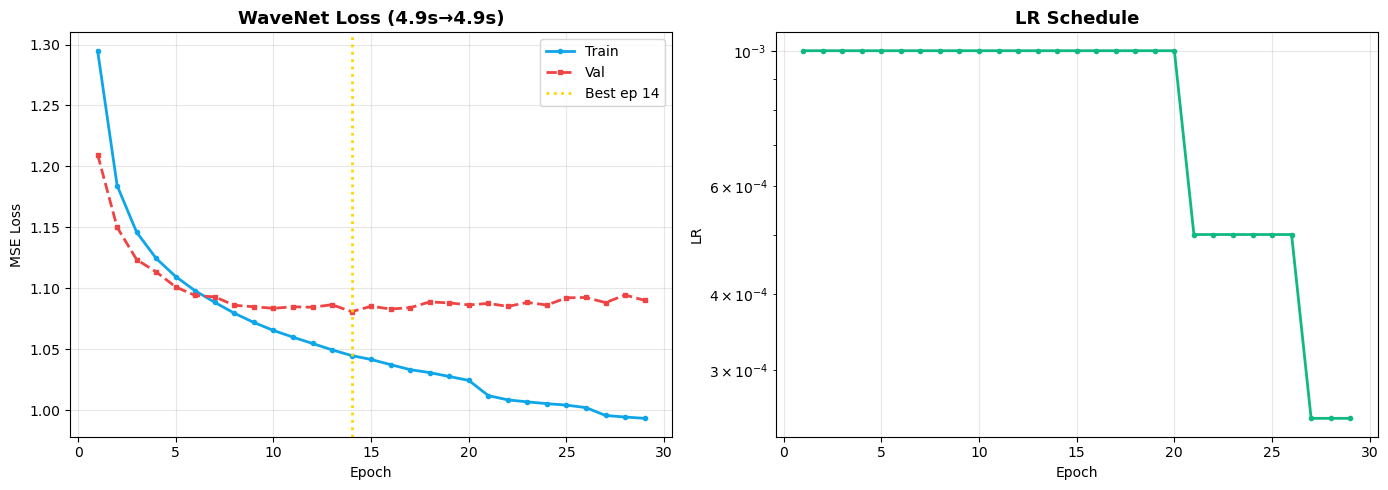

✅ Saved training_history.png


In [9]:
# CELL 9 — TRAINING HISTORY
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history['train_loss'])+1)

axes[0].plot(ep, history['train_loss'], color='#0ea5e9', lw=2,
             label='Train', marker='o', ms=3)
axes[0].plot(ep, history['val_loss'],   color='#ef4444', lw=2,
             label='Val',   marker='s', ms=3, ls='--')
best_ep = int(np.argmin(history['val_loss'])) + 1
axes[0].axvline(best_ep, color='gold', ls=':', lw=2, label=f'Best ep {best_ep}')
axes[0].set_title(f'WaveNet Loss ({INPUT_LEN/FS:.1f}s→{HORIZON/FS:.1f}s)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history['lr'], color='#10b981', lw=2, marker='o', ms=3)
axes[1].set_title('LR Schedule', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('LR')
axes[1].set_yscale('log'); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved training_history.png")

In [10]:
# CELL 10 — TEST EVALUATION
test_loss, test_preds, test_targets = eval_epoch(model, cnn_te, DEVICE)
print(f"Test MSE : {test_loss:.6f}")

mae_per_lead, rmse_per_lead = [], []
for i in range(N_LEADS):
    p = test_preds[:, :, i].flatten()
    t = test_targets[:, :, i].flatten()
    mae_per_lead.append(mean_absolute_error(t, p))
    rmse_per_lead.append(np.sqrt(mean_squared_error(t, p)))

mae_macro  = np.mean(mae_per_lead)
rmse_macro = np.mean(rmse_per_lead)

print(f"\nPer-Lead Results:")
for i, name in enumerate(LEAD_NAMES):
    print(f"  {name:>4s}: MAE={mae_per_lead[i]:.4f}  RMSE={rmse_per_lead[i]:.4f}")
print(f"\nMacro MAE  : {mae_macro:.6f} mV")
print(f"Macro RMSE : {rmse_macro:.6f} mV")
print("✅ Evaluation complete")

Test MSE : 1.070975

Per-Lead Results:
     I: MAE=0.7078  RMSE=1.0270
    II: MAE=0.6625  RMSE=0.9754
   III: MAE=0.6619  RMSE=0.9952
   aVR: MAE=0.6791  RMSE=0.9847
   aVL: MAE=0.6945  RMSE=1.0285
   aVF: MAE=0.6579  RMSE=0.9830
    V1: MAE=0.7237  RMSE=1.0819
    V2: MAE=0.6835  RMSE=1.0675
    V3: MAE=0.6813  RMSE=1.0667
    V4: MAE=0.6863  RMSE=1.0675
    V5: MAE=0.7018  RMSE=1.0682
    V6: MAE=0.7175  RMSE=1.0644

Macro MAE  : 0.688141 mV
Macro RMSE : 1.034164 mV
✅ Evaluation complete


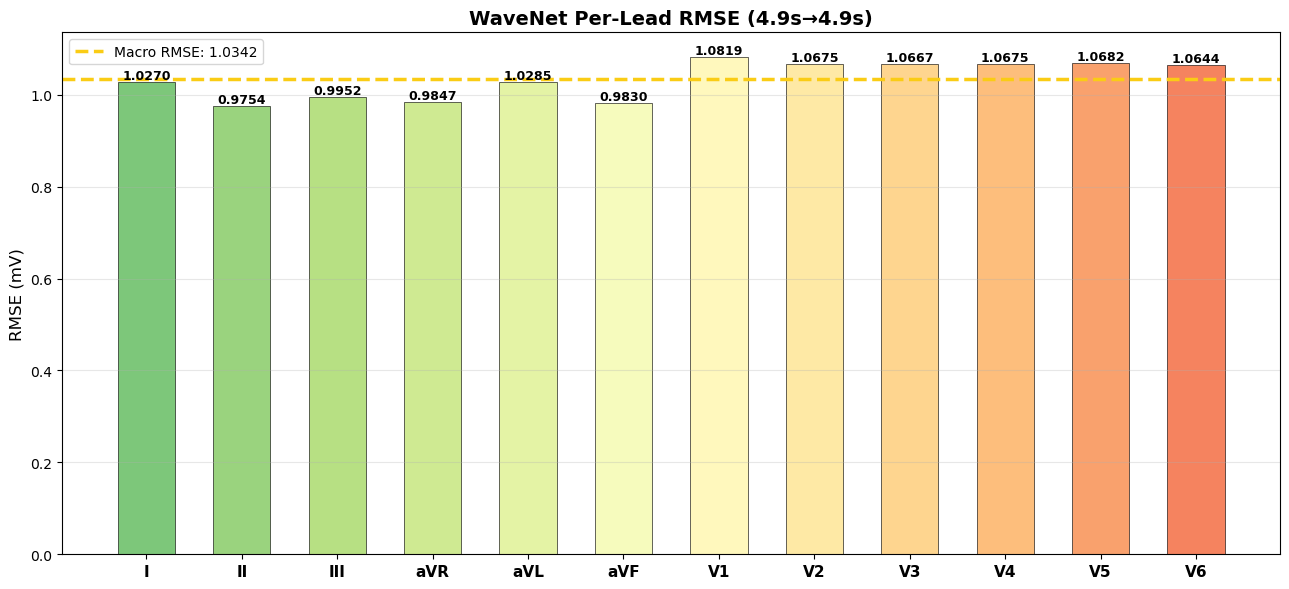

In [11]:
# CELL 11 — PER-LEAD RMSE
fig, ax = plt.subplots(figsize=(13, 6))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, N_LEADS))
bars   = ax.bar(np.arange(N_LEADS), rmse_per_lead, width=0.6,
                color=colors, alpha=0.85, edgecolor='black', lw=0.5)
ax.axhline(rmse_macro, color='#facc15', ls='--', lw=2.5,
           label=f'Macro RMSE: {rmse_macro:.4f}')
for bar, val in zip(bars, rmse_per_lead):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(np.arange(N_LEADS))
ax.set_xticklabels(LEAD_NAMES, fontsize=11, fontweight='bold')
ax.set_ylabel('RMSE (mV)', fontsize=12)
ax.set_title(f'WaveNet Per-Lead RMSE ({INPUT_LEN/FS:.1f}s→{HORIZON/FS:.1f}s)',
             fontsize=14, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'per_lead_rmse.png'), dpi=150, bbox_inches='tight')
plt.show()

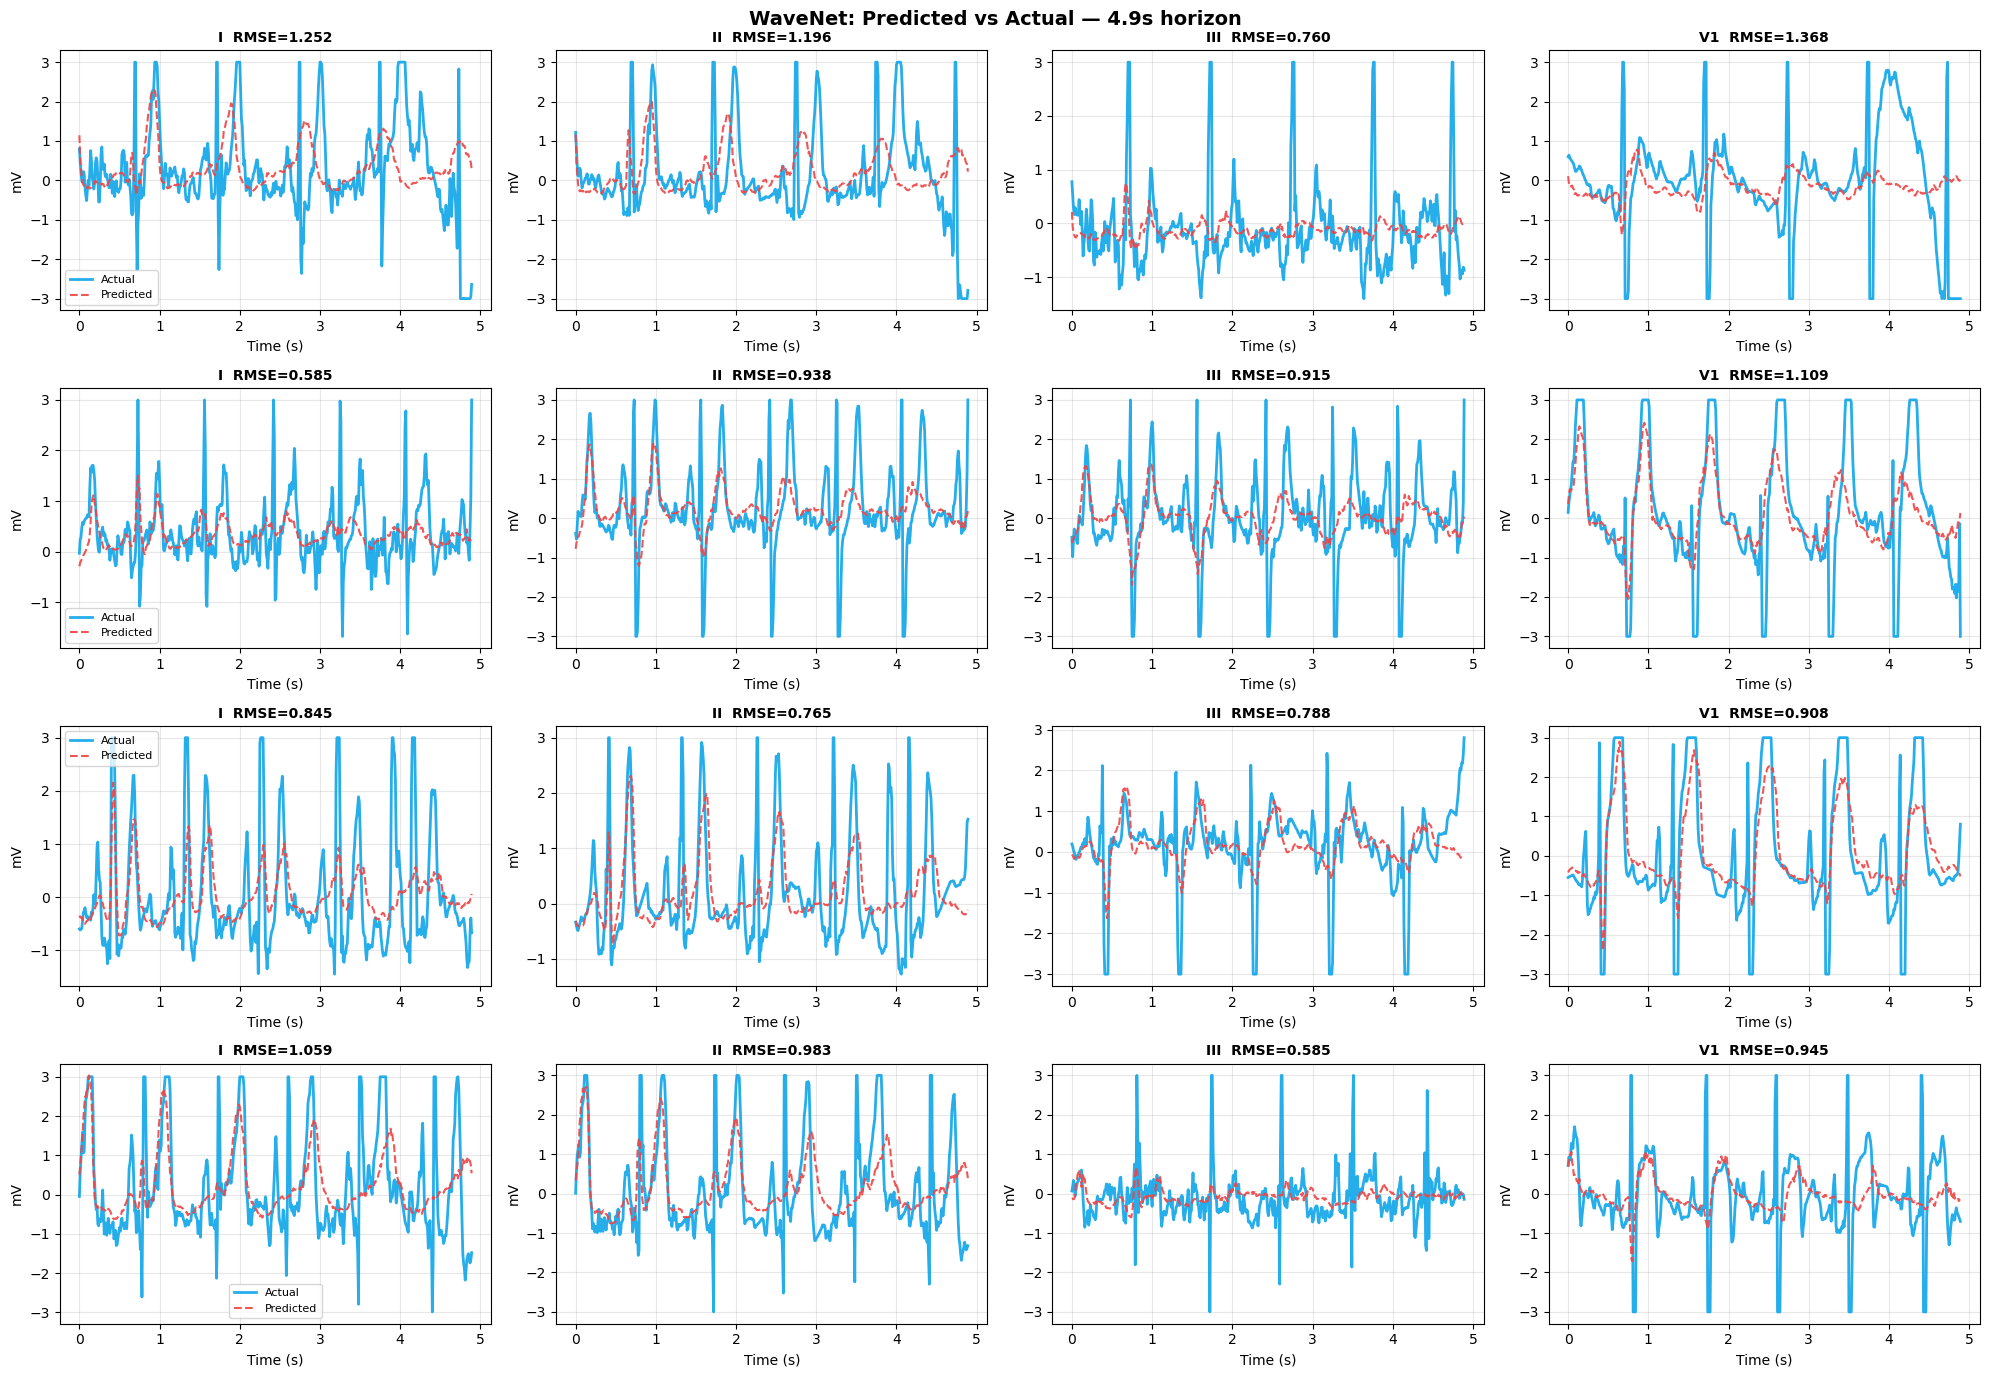

✅ Overlay saved


In [12]:
# CELL 12 — PREDICTED vs ACTUAL (spike check)
n_samples    = 4
lead_indices = [0, 1, 2, 6]   # I, II, III, V1
t = np.arange(HORIZON) / FS

fig, axes = plt.subplots(n_samples, 4, figsize=(20, 14))
for row in range(n_samples):
    for col, lead_idx in enumerate(lead_indices):
        ax     = axes[row, col]
        actual = test_targets[row, :, lead_idx]
        pred   = test_preds[row,   :, lead_idx]

        ax.plot(t, actual, color='#0ea5e9', lw=2,   label='Actual',    alpha=0.9)
        ax.plot(t, pred,   color='#ef4444', lw=1.5, label='Predicted', alpha=0.9, ls='--')

        rmse_i = np.sqrt(mean_squared_error(actual, pred))
        ax.set_title(f'{LEAD_NAMES[lead_idx]}  RMSE={rmse_i:.3f}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('mV')
        ax.grid(True, alpha=0.3)
        if col == 0: ax.legend(fontsize=8)

fig.suptitle(f'WaveNet: Predicted vs Actual — {HORIZON/FS:.1f}s horizon',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'predictions_overlay.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Overlay saved")

Baseline MAE (flat regions) : 0.4611 mV
Spike MAE   (|sig| > 1.5σ)  : 2.0877 mV
Spike/base ratio            : 4.53x
⚠  Partial spike tracking


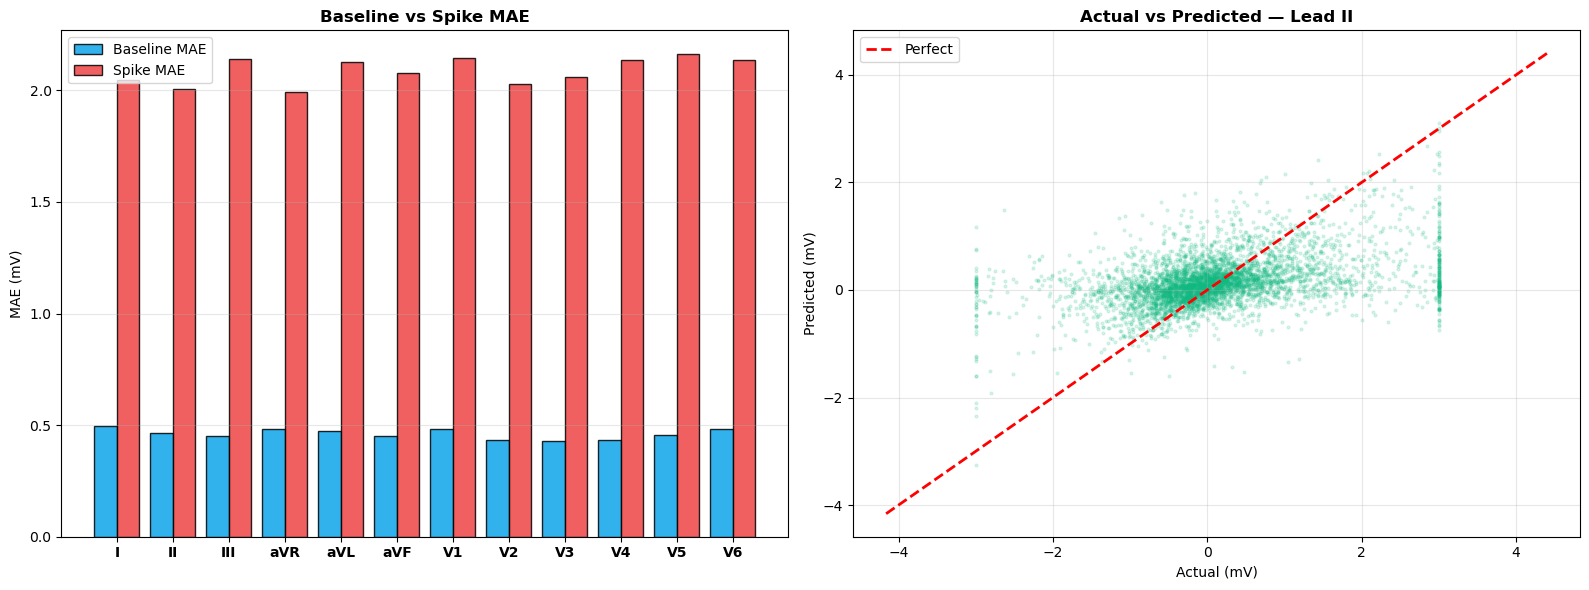

✅ Spike analysis saved


In [13]:
# CELL 13 — SPIKE TRACKING ANALYSIS
spike_mae, base_mae = [], []
for i in range(N_LEADS):
    actual = test_targets[:, :, i]
    pred   = test_preds[:,   :, i]
    thresh = actual.std() * 1.5
    sm = np.abs(actual) > thresh
    bm = ~sm
    if sm.sum() > 0: spike_mae.append(np.abs(actual[sm] - pred[sm]).mean())
    if bm.sum() > 0: base_mae.append( np.abs(actual[bm] - pred[bm]).mean())

spike_mean = np.mean(spike_mae)
base_mean  = np.mean(base_mae)
ratio      = spike_mean / base_mean

print(f"Baseline MAE (flat regions) : {base_mean:.4f} mV")
print(f"Spike MAE   (|sig| > 1.5σ)  : {spike_mean:.4f} mV")
print(f"Spike/base ratio            : {ratio:.2f}x")
if   ratio < 2.5: print("✅ Excellent spike tracking")
elif ratio < 4.0: print("✅ Good spike tracking")
elif ratio < 6.0: print("⚠  Partial spike tracking")
else:             print("❌ Spikes still missed")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart
x = np.arange(N_LEADS)
bm_l, sm_l = [], []
for i in range(N_LEADS):
    a = test_targets[:,:,i]; p = test_preds[:,:,i]
    thr = a.std()*1.5
    sm  = np.abs(a) > thr; bm = ~sm
    sm_l.append(np.abs(a[sm]-p[sm]).mean() if sm.sum()>0 else 0)
    bm_l.append(np.abs(a[bm]-p[bm]).mean() if bm.sum()>0 else 0)

axes[0].bar(x-0.2, bm_l, 0.4, label='Baseline MAE',
            color='#0ea5e9', alpha=0.85, edgecolor='black')
axes[0].bar(x+0.2, sm_l, 0.4, label='Spike MAE',
            color='#ef4444', alpha=0.85, edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(LEAD_NAMES, fontsize=10, fontweight='bold')
axes[0].set_ylabel('MAE (mV)'); axes[0].legend()
axes[0].set_title('Baseline vs Spike MAE', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Scatter actual vs predicted (Lead II)
af = test_targets[:,:,1].flatten(); pf = test_preds[:,:,1].flatten()
idx = np.random.choice(len(af), 5000, replace=False)
axes[1].scatter(af[idx], pf[idx], alpha=0.15, s=4, color='#10b981')
mn = min(af.min(), pf.min()); mx = max(af.max(), pf.max())
axes[1].plot([mn,mx],[mn,mx],'r--',lw=2,label='Perfect')
axes[1].set_xlabel('Actual (mV)'); axes[1].set_ylabel('Predicted (mV)')
axes[1].set_title('Actual vs Predicted — Lead II', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'spike_tracking.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Spike analysis saved")

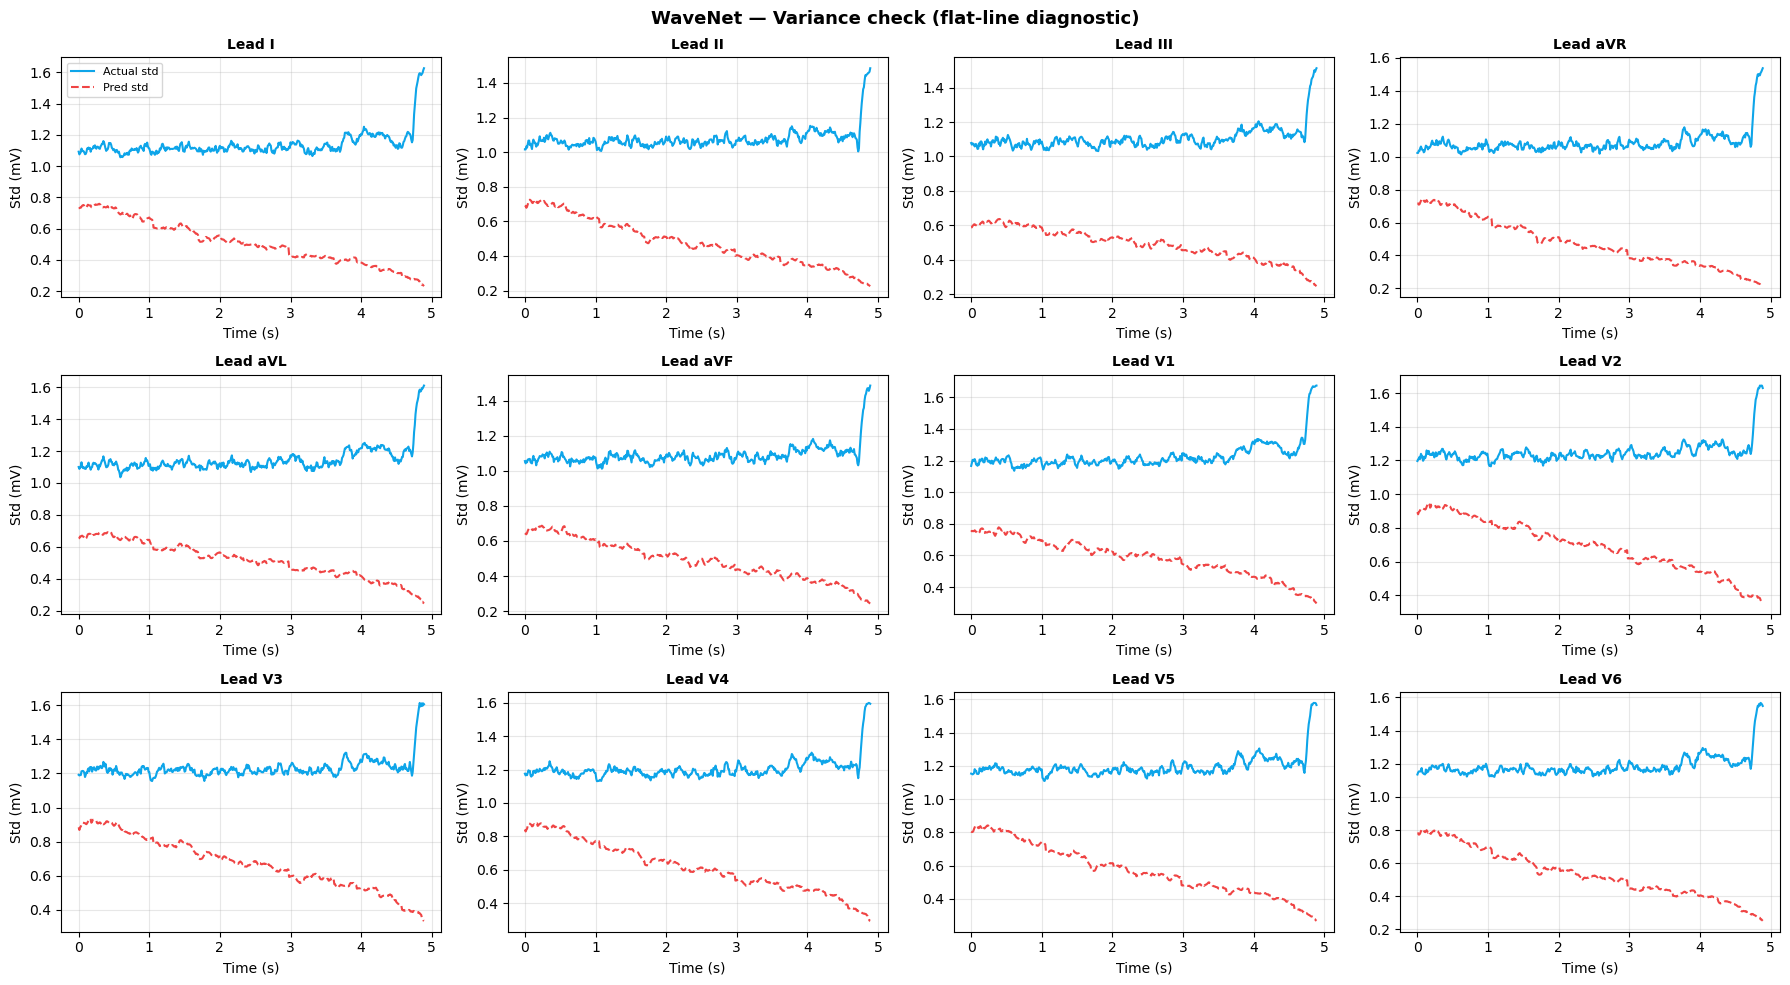

Min pred std: 0.2140  ✅ No flat lines


In [14]:
# CELL 14 — FLAT-LINE CHECK
pred_std = test_preds.std(axis=0)
true_std = test_targets.std(axis=0)
t = np.arange(HORIZON) / FS

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
for i, (ax, name) in enumerate(zip(axes.flatten(), LEAD_NAMES)):
    ax.plot(t, true_std[:, i], color='#0ea5e9', lw=1.5, label='Actual std')
    ax.plot(t, pred_std[:, i], color='#ef4444', lw=1.5, label='Pred std', ls='--')
    ax.set_title(f'Lead {name}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Std (mV)'); ax.grid(alpha=0.3)
    if i == 0: ax.legend(fontsize=8)
    if pred_std[:, i].min() < 0.01:
        ax.set_facecolor('#fff0f0')
        ax.set_title(f'Lead {name} ⚠ flat?', color='red', fontweight='bold', fontsize=10)

fig.suptitle('WaveNet — Variance check (flat-line diagnostic)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'variance_check.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Min pred std: {pred_std.min():.4f}  "
      f"{'✅ No flat lines' if pred_std.min() >= 0.01 else '⚠ flat?'}")

In [15]:
# CELL 15 — SAVE RESULTS
results = {
    'model': 'WaveNet',
    'horizon_s': HORIZON/FS, 'input_s': INPUT_LEN/FS,
    'n_parameters': n_params, 'test_mse': test_loss,
    'mae_per_lead': mae_per_lead, 'mae_macro': mae_macro,
    'rmse_per_lead': rmse_per_lead, 'rmse_macro': rmse_macro,
    'history': history, 'lead_names': LEAD_NAMES,
    'test_preds': test_preds, 'test_targets': test_targets,
}
path = os.path.join(CKPT_DIR, 'CNN-LSTM_results_summary.pkl')
with open(path, 'wb') as f: pickle.dump(results, f)

print(f"{'='*60}")
print(f"  WaveNet FINAL  ({INPUT_LEN/FS:.1f}s → {HORIZON/FS:.1f}s)")
print(f"{'='*60}")
print(f"  Params     : {n_params:,}")
print(f"  Test MSE   : {test_loss:.6f}")
print(f"  Macro MAE  : {mae_macro:.6f} mV")
print(f"  Macro RMSE : {rmse_macro:.6f} mV")
print(f"  Saved      → {path}")
print("✅ Done!")

  WaveNet FINAL  (4.9s → 4.9s)
  Params     : 409,100
  Test MSE   : 1.070975
  Macro MAE  : 0.688141 mV
  Macro RMSE : 1.034164 mV
  Saved      → ../reports/checkpoints/CNN-LSTM_results_summary.pkl
✅ Done!
